In [2]:
library(repr)
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)
library(showtext)
font_add_google("Lato", "lato")
showtext_opts(dpi = 300)
showtext_auto()

Loading required package: sysfonts

Loading required package: showtextdb



In [3]:
df <- read_csv("median_io_group_gaze.csv")
df <- df |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        PID = factor(PID)
    ) |>
    rename(
        building_location = inside,
        group = category
    )

Rows: 1829 Columns: 6
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (4): PID, inside, GroupCount, median_clusterDuration

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
# df |> ggplot(aes(x = group, y = median_clusterDuration, color = building_location)) +
#  geom_point(position = position_dodge(0.4)) +
#  theme_minimal()
df |> head()

PID,hitObjectColliderName,group,building_location,GroupCount,median_clusterDuration
<fct>,<chr>,<chr>,<fct>,<dbl>,<dbl>
4003,Building_100,peripheral,outside,10,0.4109216
4003,Building_101,peripheral,outside,8,0.4438699
4003,Building_102,peripheral,outside,15,0.3658845
4003,Building_131,peripheral,outside,2,0.5775331
4003,Building_132,peripheral,outside,3,0.3659341
4003,Building_139,peripheral,outside,7,0.3102803


Warning message:
“Removed 55 rows containing non-finite outside the scale range (`stat_density()`).”


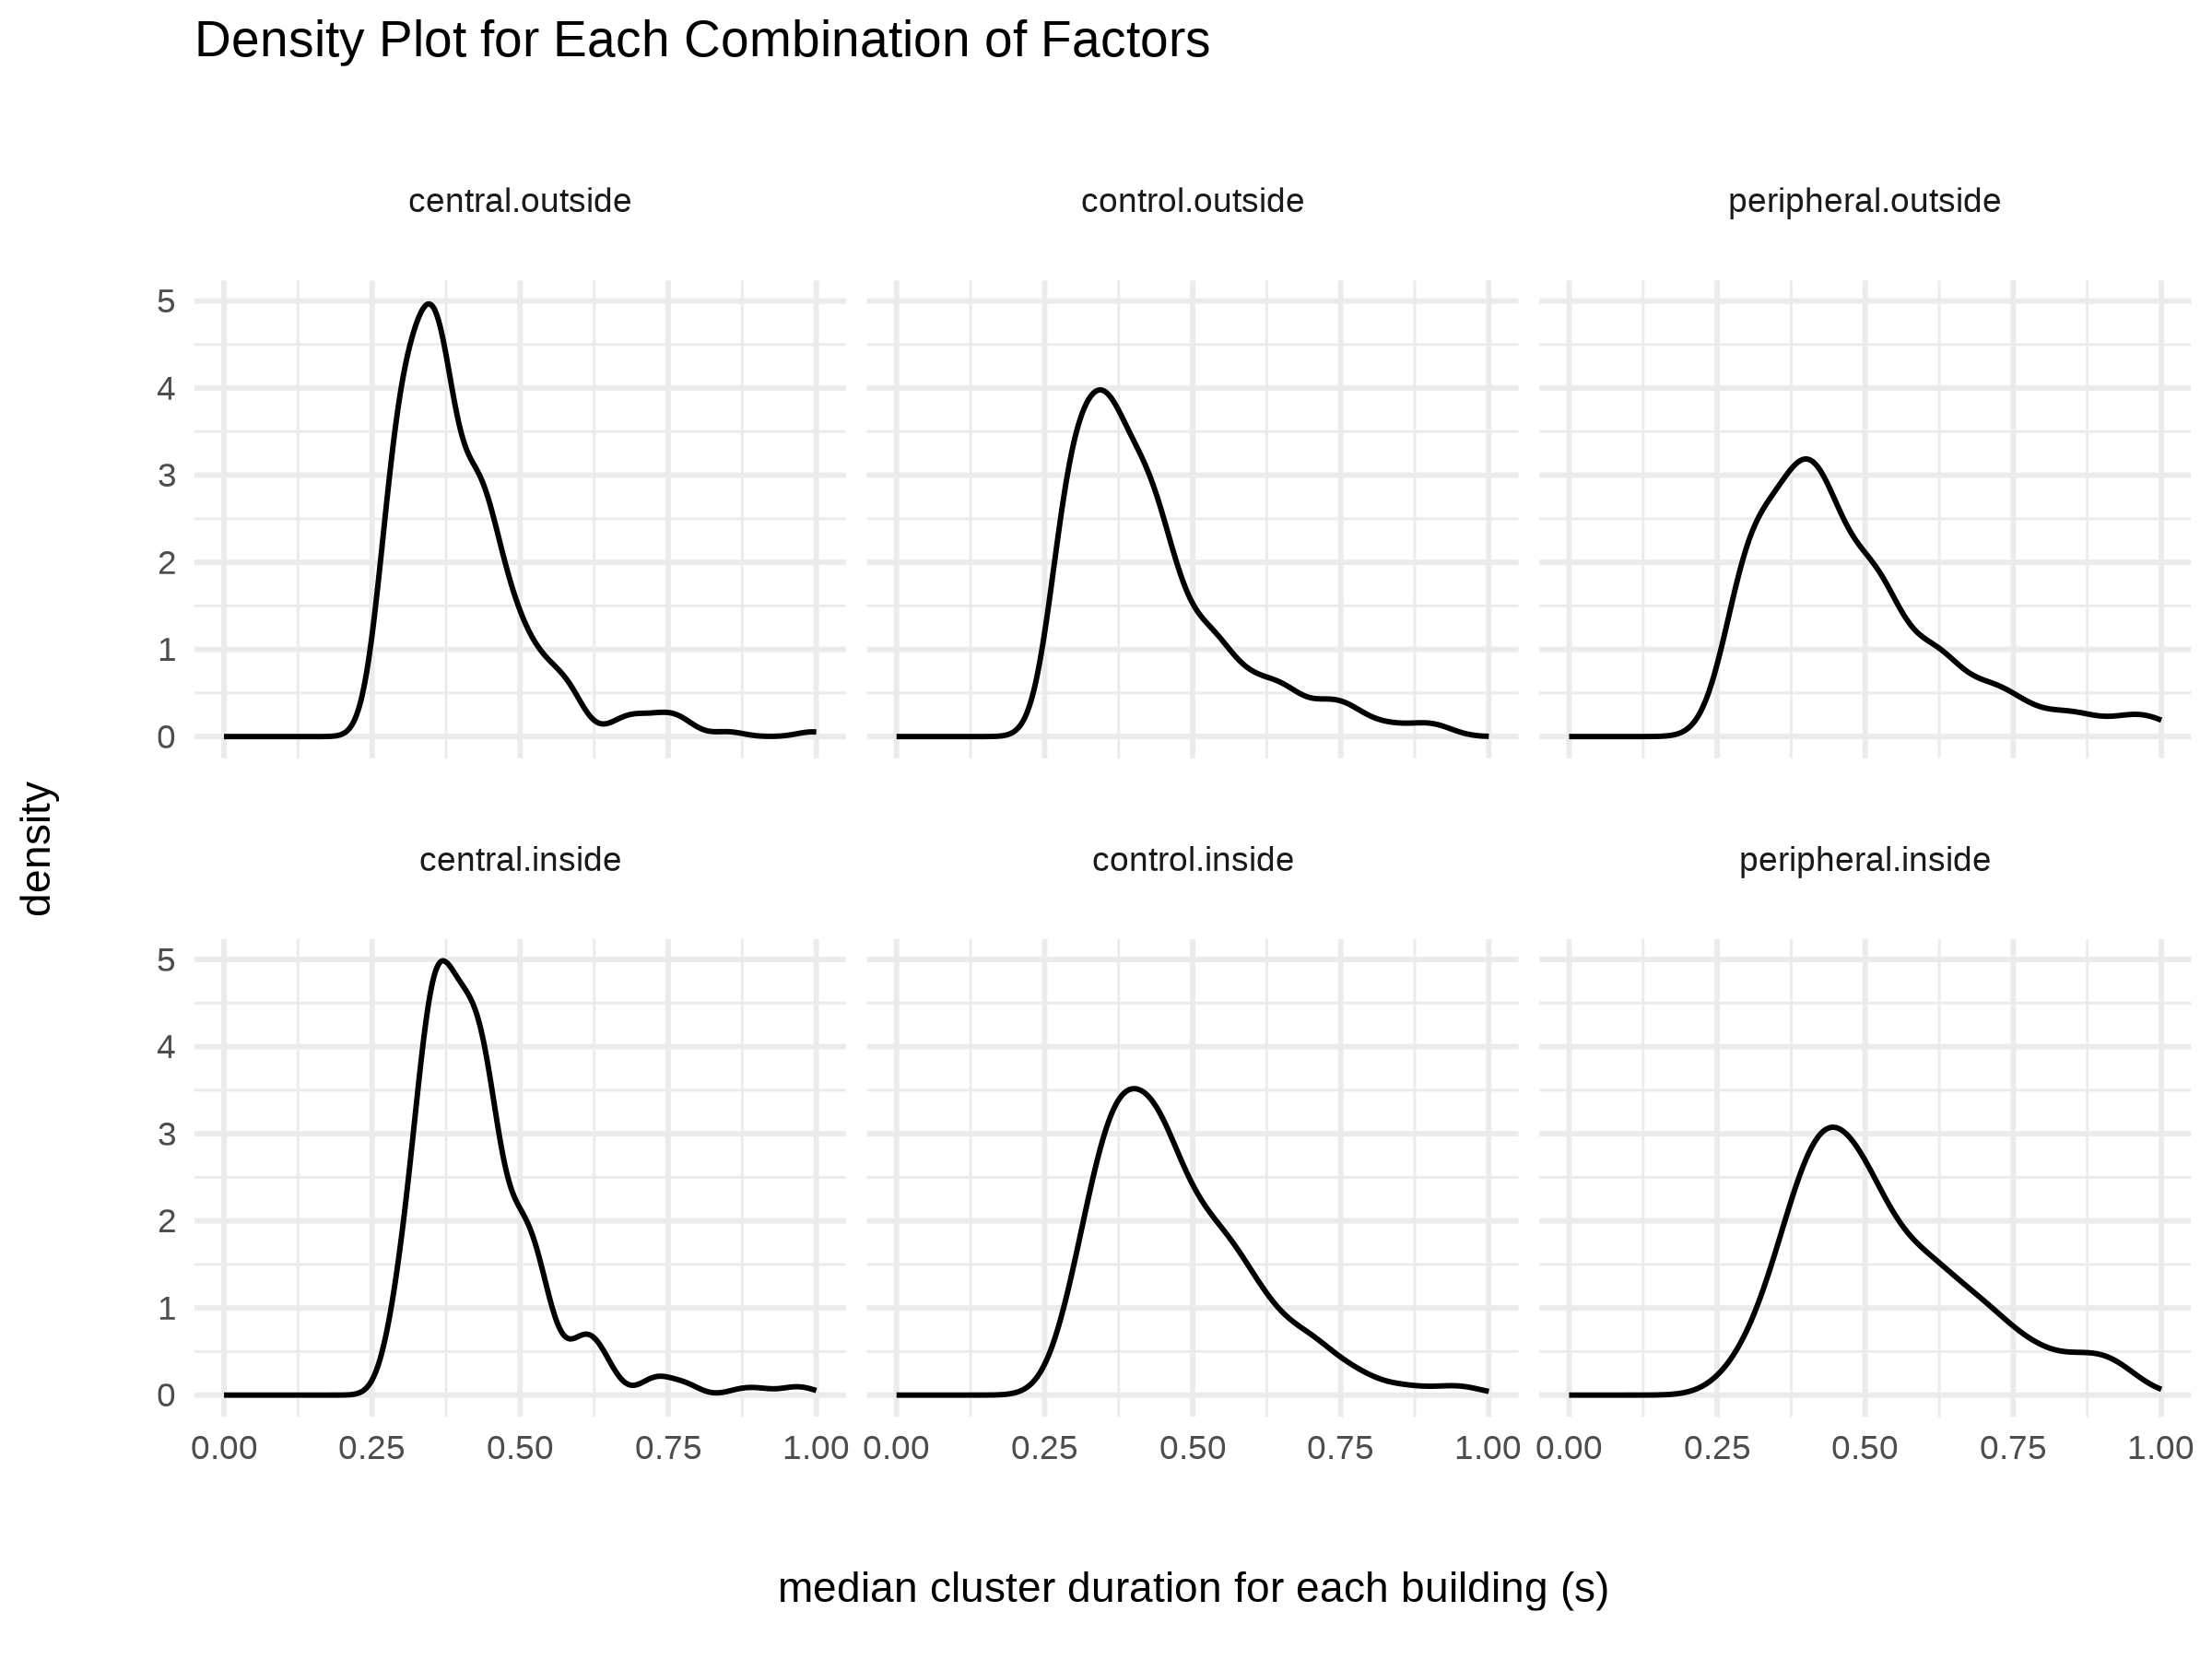

In [5]:
fig <- df |>
  ggplot(aes(x = median_clusterDuration)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  xlim(0, 1) +
  facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
  theme_minimal() +
  labs(title = "Density Plot for Each Combination of Factors",
       x = "median cluster duration for each building (s)",
       y = "density")
fig
#ggsave("naisu_only_location.svg", fig)

In [21]:
library(lme4)
library(emmeans)
library(performance)
library(pbkrtest)
library(lmerTest)


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'


Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step




In [ ]:
# Fit a generalized linear mixed model (GLMM) using glmer
# Assuming a dataset 'data' with a binary response variable 'y', 
# a fixed effect 'x', and a random effect 'group'

model <- glmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1| hitObjectColliderName), data = df, Gamma(link = "inverse"))
model0 <- glmer(median_clusterDuration ~ 1 + (1 | PID) + (1| hitObjectColliderName), data = df, Gamma(link = "inverse"))

In [7]:
an <- anova(model, model0)

In [124]:
an

,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model0,4,-1842.978,-1820.932,925.4889,-1850.978,NA,NA,NA
model,7,-1865.454,-1826.873,939.7269,-1879.454,28.47611,3,2.885294e-06


In [16]:
anova(model)
library(car)
Anova(model)
anova(model)

,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
building_location,1,3.598557,3.598557,26.46256
group,2,5.930016,2.965008,21.80366


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
building_location,13.52964,1,2.348256e-04
group,26.85674,2,1.472765e-06


,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
building_location,1,3.598557,3.598557,26.46256
group,2,5.930016,2.965008,21.80366


In [13]:
lme_model <- lmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1| hitObjectColliderName), data = df)
summary(lme_model)

anova(lme_model)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: median_clusterDuration ~ building_location + group + (1 | PID) +  
    (1 | hitObjectColliderName)
   Data: df

REML criterion at convergence: -441.4

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.9650 -0.4927 -0.1717  0.2174  9.6951 

Random effects:
 Groups                Name        Variance Std.Dev.
 hitObjectColliderName (Intercept) 0.005085 0.07131 
 PID                   (Intercept) 0.001148 0.03388 
 Residual                          0.042117 0.20522 
Number of obs: 1829, groups:  hitObjectColliderName, 127; PID, 24

Fixed effects:
                         Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)               0.39243    0.01815  46.38773  21.626  < 2e-16 ***
building_locationinside   0.06303    0.01754 104.56649   3.594 0.000499 ***
groupcontrol              0.04218    0.02062  20.64393   2.045 0.053785 .  
groupperipheral           0.12912    0

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
building_location,0.5439095,0.5439095,1,104.56649,12.91421,4.990153e-04
group,1.6890800,0.8445400,2,20.86773,20.05217,1.384876e-05


In [11]:
# Create a reference grid
ref_grid <- ref_grid(model)
02
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ group)

# View results
summary(emm)
pairs(emm, adjust = "bonferroni")
pairs(emm, adjust = "tukey")


[1] 2

,group,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,central,0.4004916,0.01403742,Inf,0.3729788,0.4280045
2,control,0.4331715,0.01687320,Inf,0.4001006,0.4662423
3,peripheral,0.4982905,0.02314888,Inf,0.4529195,0.5436614


 contrast             estimate     SE  df z.ratio p.value
 central - control     -0.0327 0.0166 Inf  -1.972  0.1458
 central - peripheral  -0.0978 0.0210 Inf  -4.646  <.0001
 control - peripheral  -0.0651 0.0216 Inf  -3.013  0.0078

Results are averaged over the levels of: building_location 
P value adjustment: bonferroni method for 3 tests 

 contrast             estimate     SE  df z.ratio p.value
 central - control     -0.0327 0.0166 Inf  -1.972  0.1191
 central - peripheral  -0.0978 0.0210 Inf  -4.646  <.0001
 control - peripheral  -0.0651 0.0216 Inf  -3.013  0.0073

Results are averaged over the levels of: building_location 
P value adjustment: tukey method for comparing a family of 3 estimates 

Warning message in grid.Call.graphics(C_segments, x$x0, x$y0, x$x1, x$y1, x$arrow):
“semi-transparency is not supported on this device: reported only once per page”


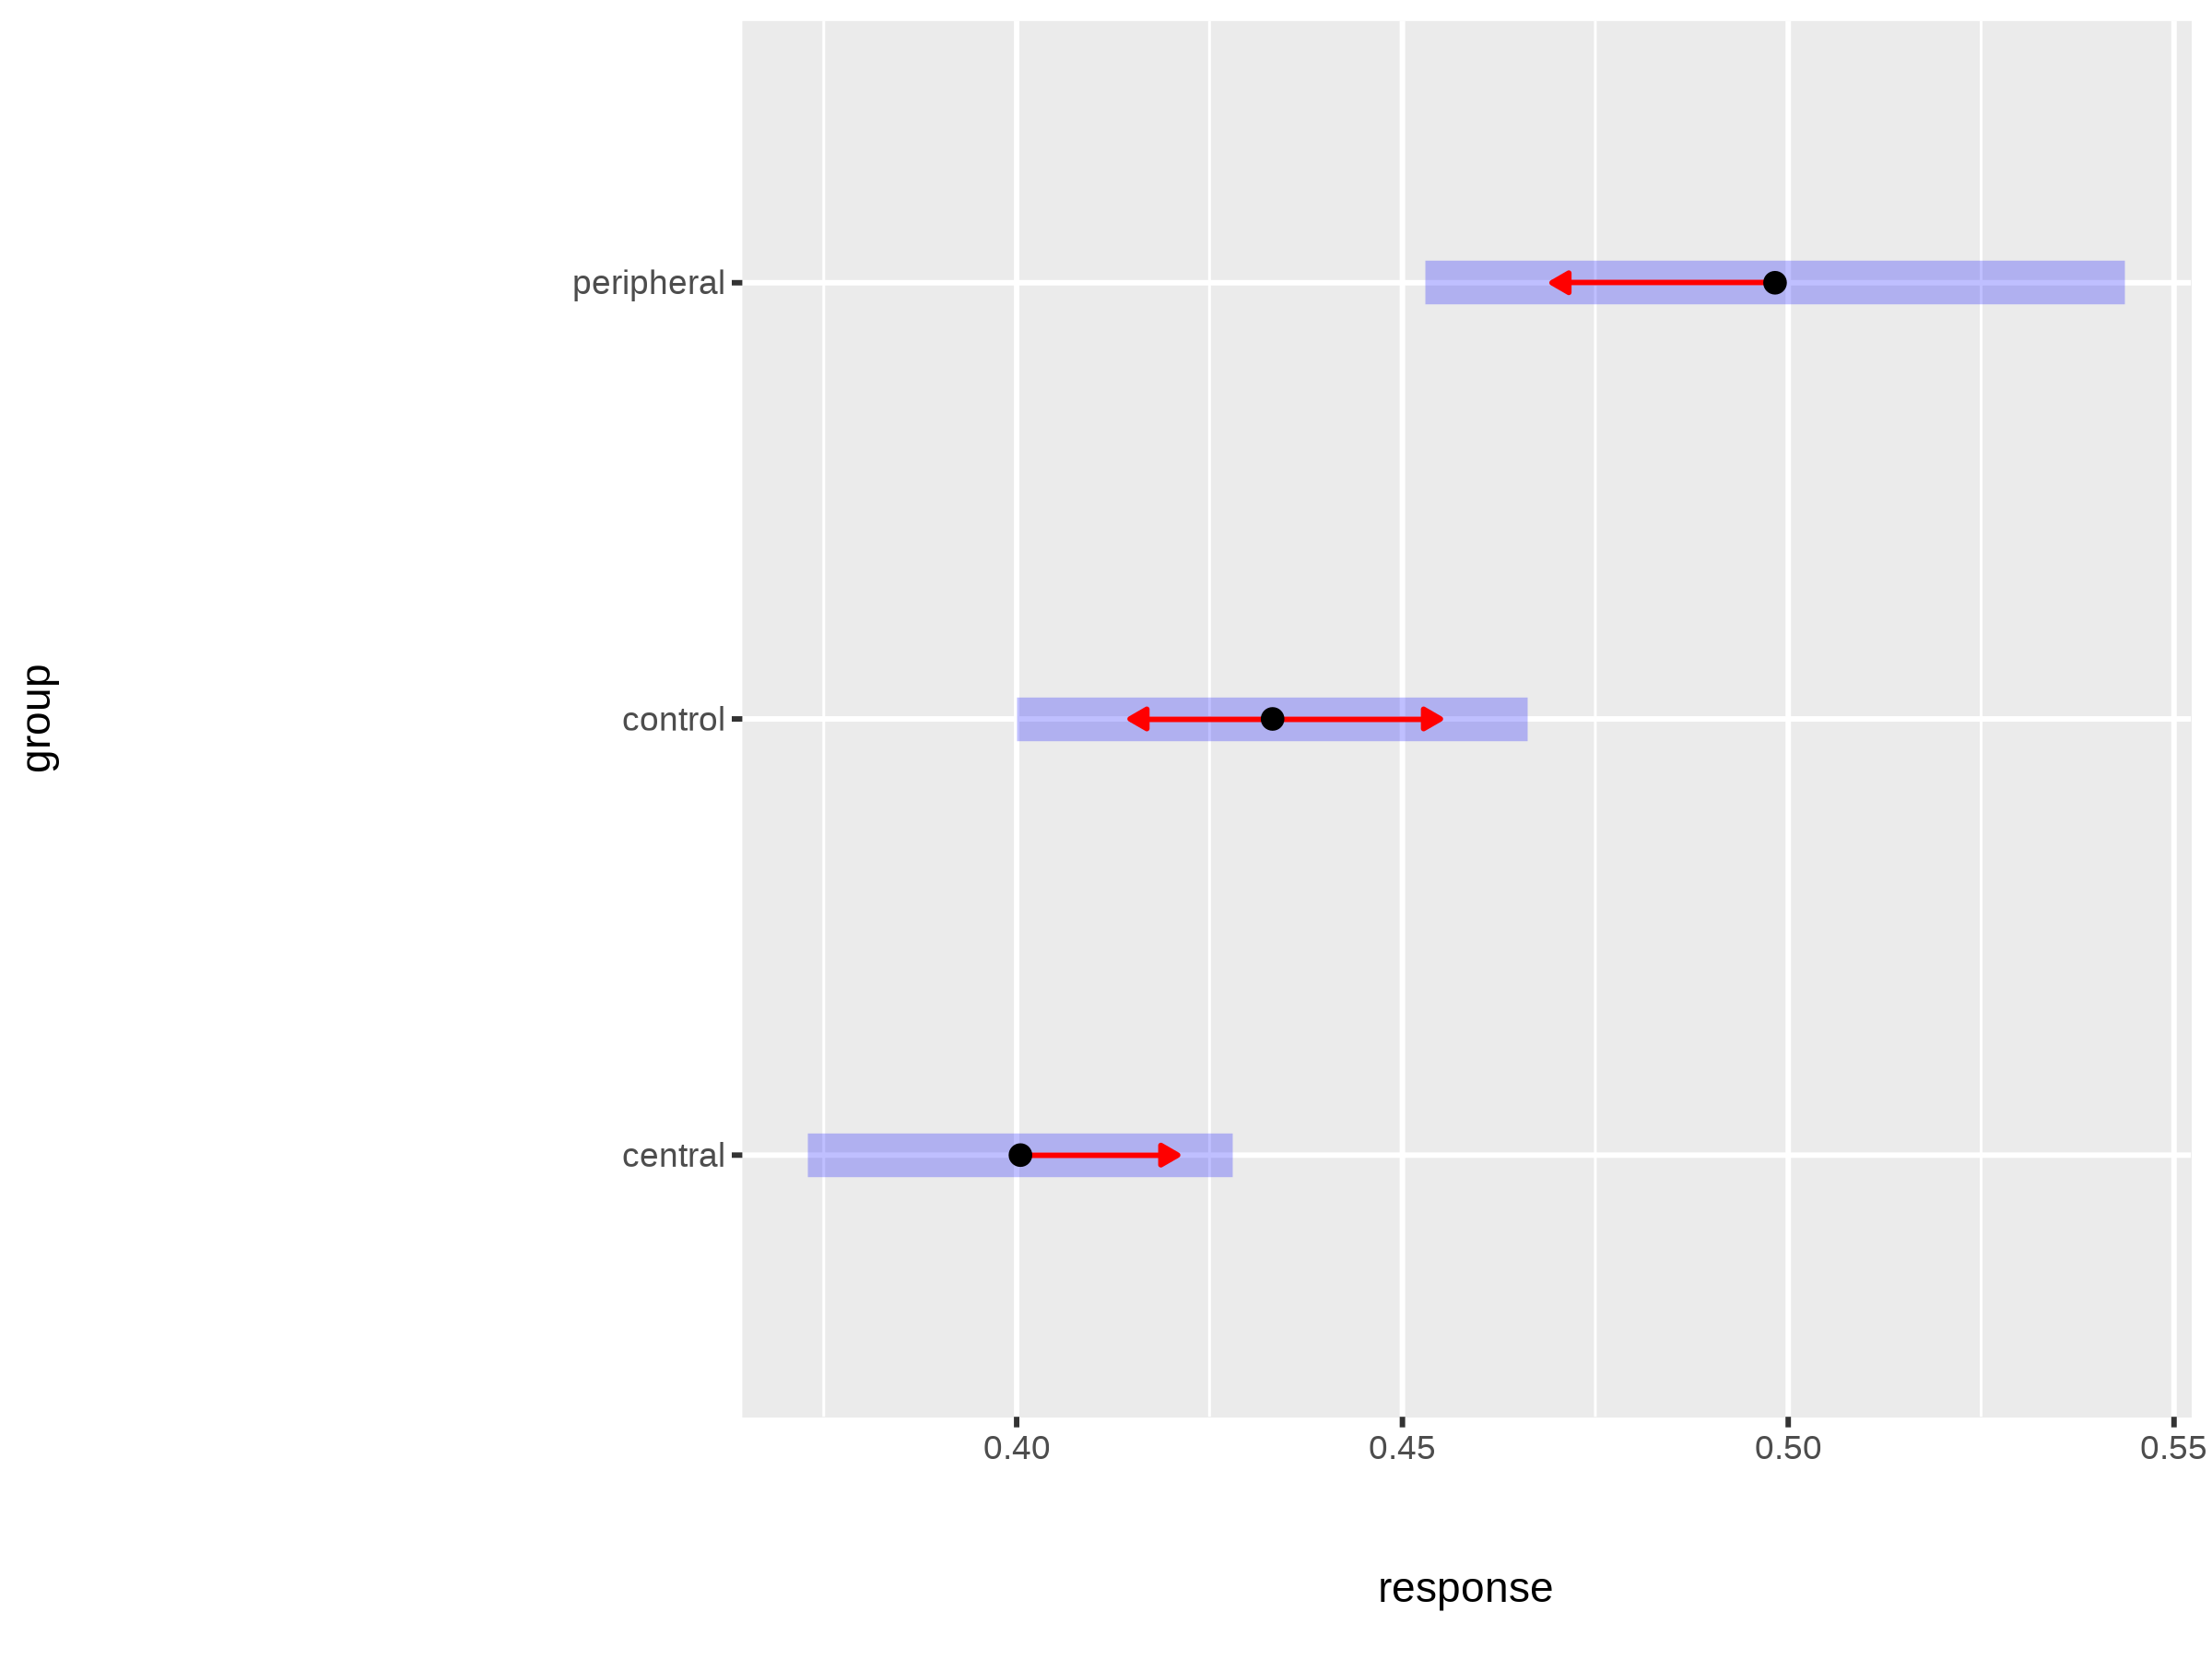

In [126]:
plot(emm, comparisons = TRUE)

In [129]:
r2_nakagawa(model, by_group = TRUE)
r2_nakagawa(model)

,Level,R2
,<chr>,<dbl>
,Level 1,0.01841684
PID,PID,0.53912938
hitObjectColliderName,hitObjectColliderName,0.12725529


# R2 for Mixed Models

  Conditional R2: 0.549
     Marginal R2: 0.233

In [44]:
df_node <- read_csv("io_node_group_gaze.csv")

df_node <- df_node |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        hitObjectColliderName = factor(hitObjectColliderName),
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control"))
    ) |>
    rename(
        building_location = inside,
        group = category,
        building = hitObjectColliderName,
        duration = clusterDuration
    )

df_node |> head()


Rows: 17925 Columns: 8
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (6): clusterID, sampleNr, clusterDuration, PID, inside, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


clusterID,sampleNr,duration,building,PID,group,building_location,connections
<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<dbl>
2,121,1.3477349,TaskBuilding_35,4003,peripheral,inside,17
7,35,0.3888457,Building_166,4003,peripheral,inside,12
9,39,0.4330869,Building_168,4003,peripheral,inside,11
10,33,0.3671408,TaskBuilding_42,4003,peripheral,inside,12
12,57,0.6329131,Building_166,4003,peripheral,inside,12
13,56,0.6199913,Building_166,4003,peripheral,inside,12


`summarise()` has grouped output by 'PID', 'building', 'group', 'building_location'. You can override using the
`.groups` argument.


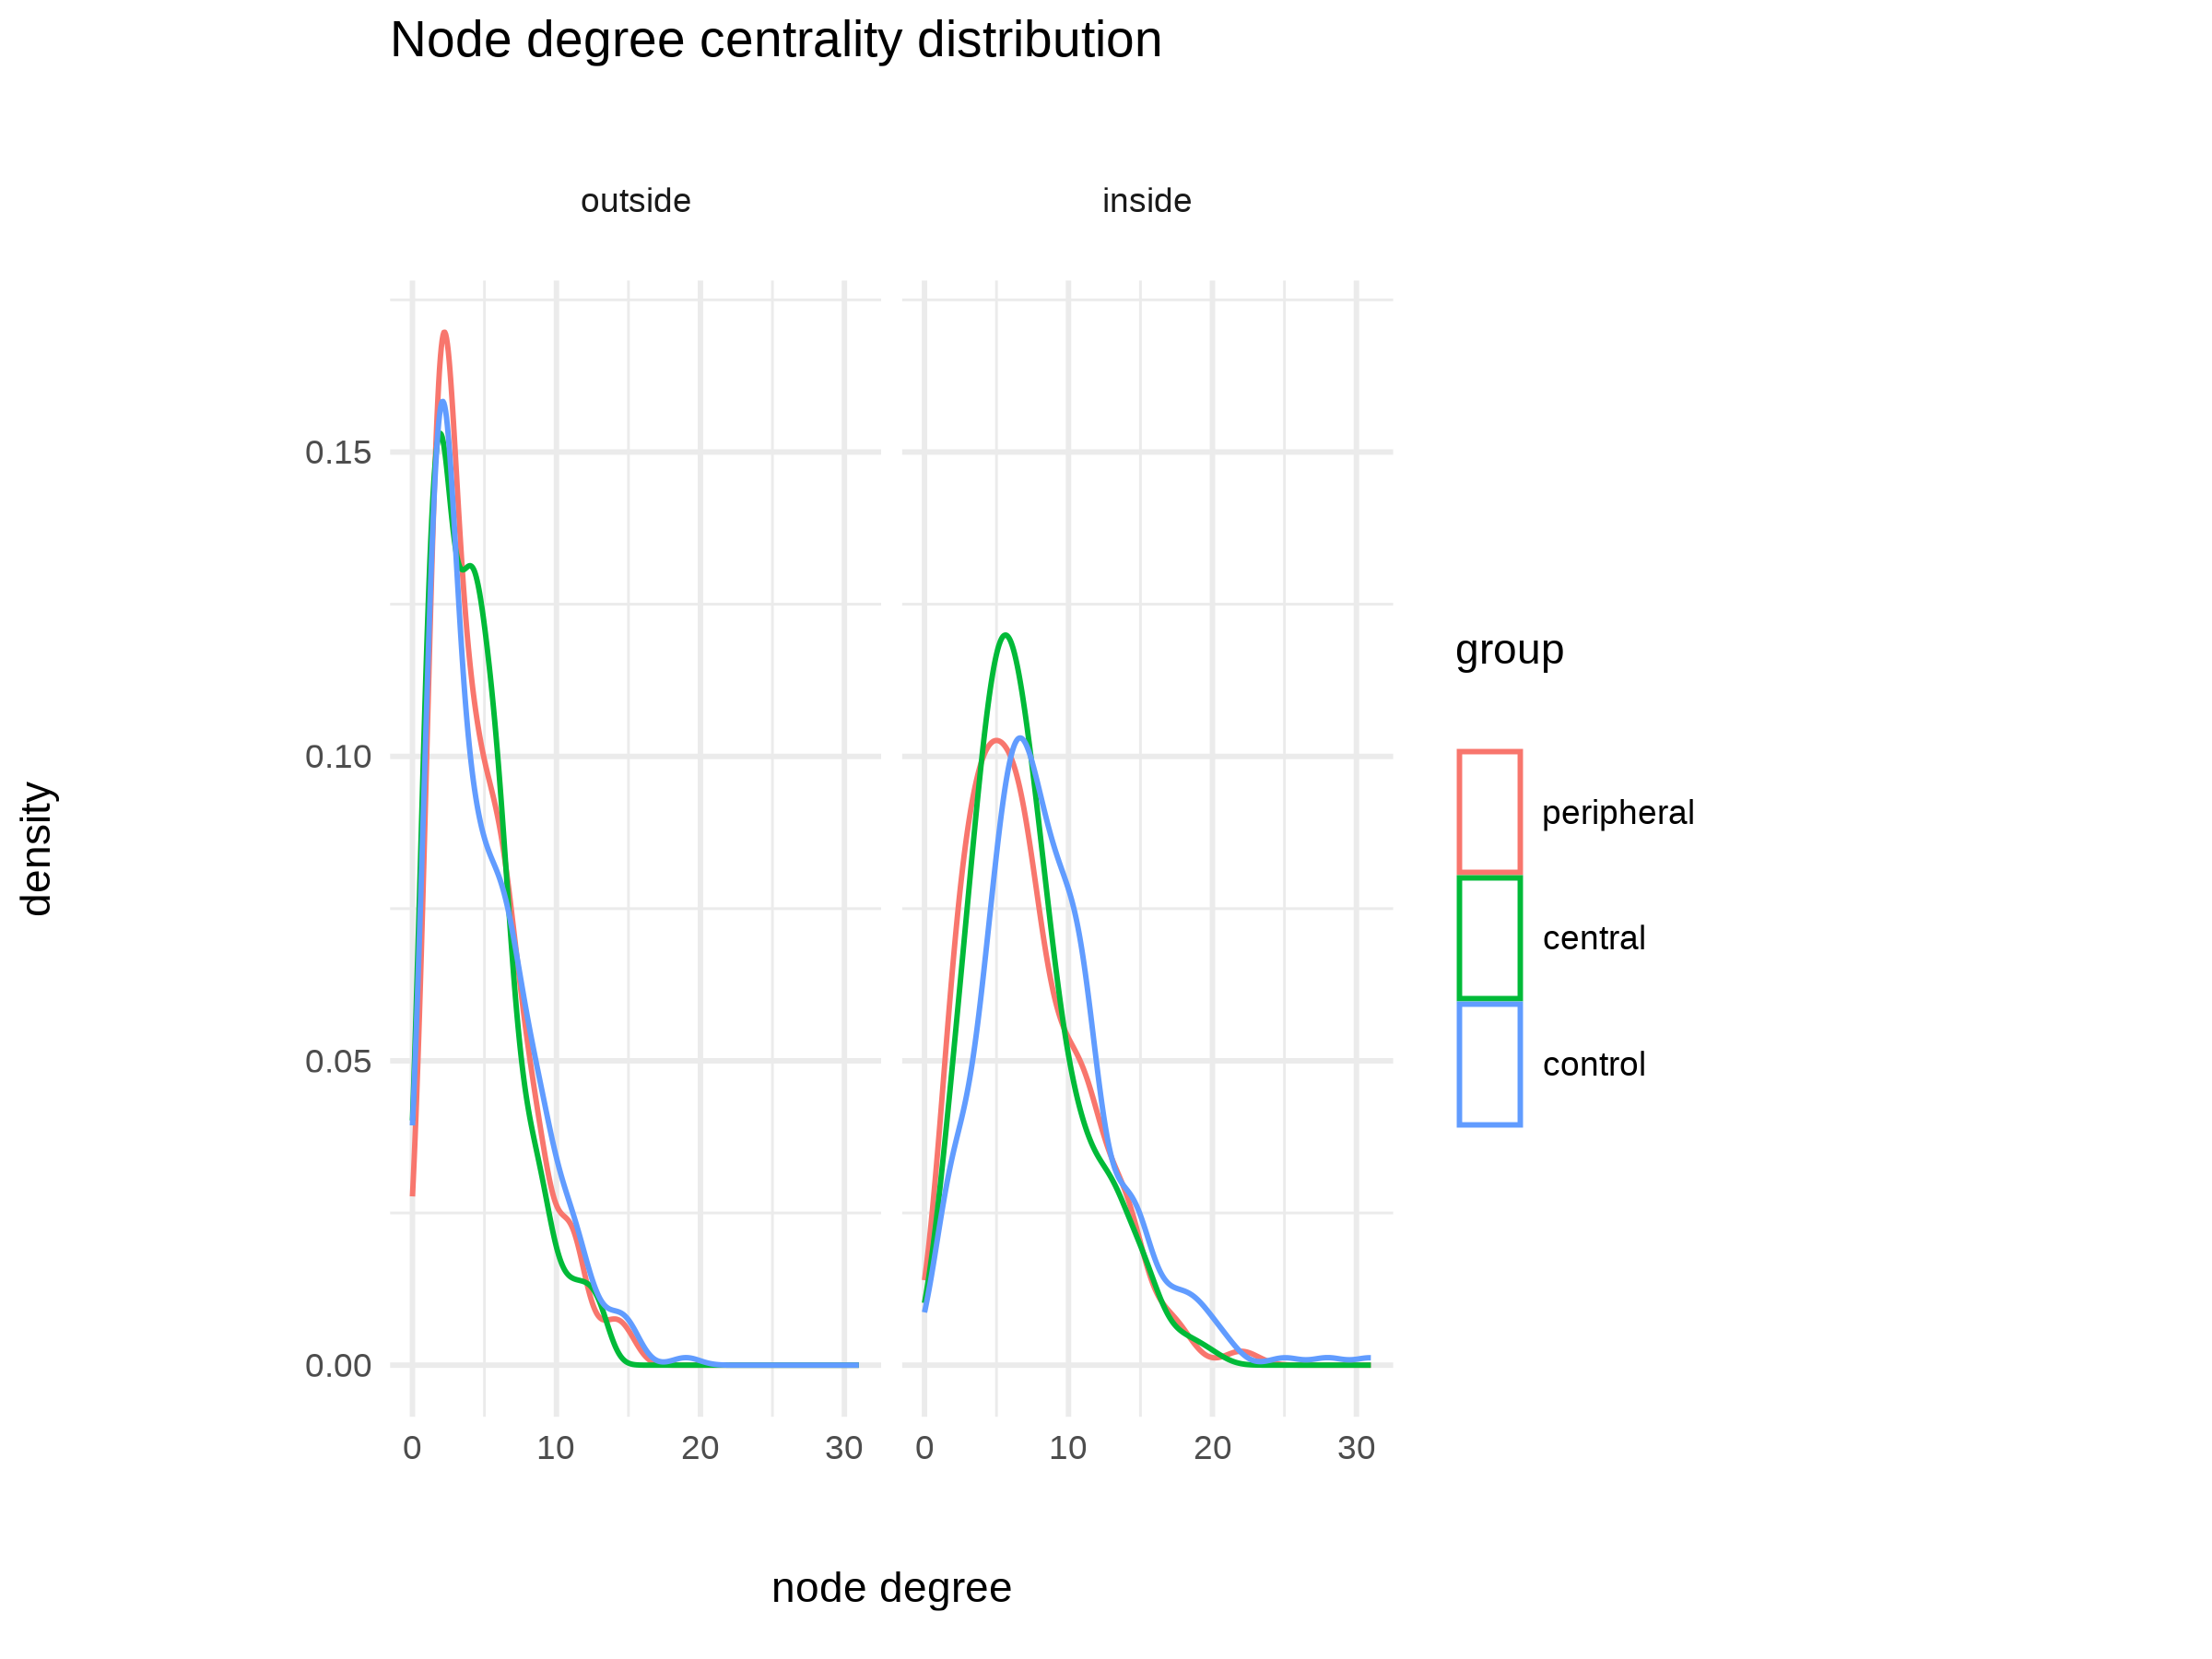

In [57]:
fig <- df_node |>
    group_by(PID, building, group, building_location, connections) |>
    summarise(median_duration = median(duration)) |>
    ungroup() |>
    ggplot(aes(x = connections, group = group, color = group)) +
      geom_density(alpha = 0.6) +  # Adjust alpha for transparency
      facet_wrap(~ building_location) +  # Facet by the interaction of the two factors
      theme_minimal() +
      labs(title = "Node degree centrality distribution",
           x = "node degree",
           y = "density")
fig

In [47]:
df_group_node <- df_node |>
    group_by(PID, building, group, building_location, connections) |>
    summarise(median_duration = median(duration)) |>
    ungroup()

`summarise()` has grouped output by 'PID', 'building', 'group', 'building_location'. You can override using the
`.groups` argument.


Warning message:
“Removed 2585 rows containing non-finite outside the scale range (`stat_density()`).”


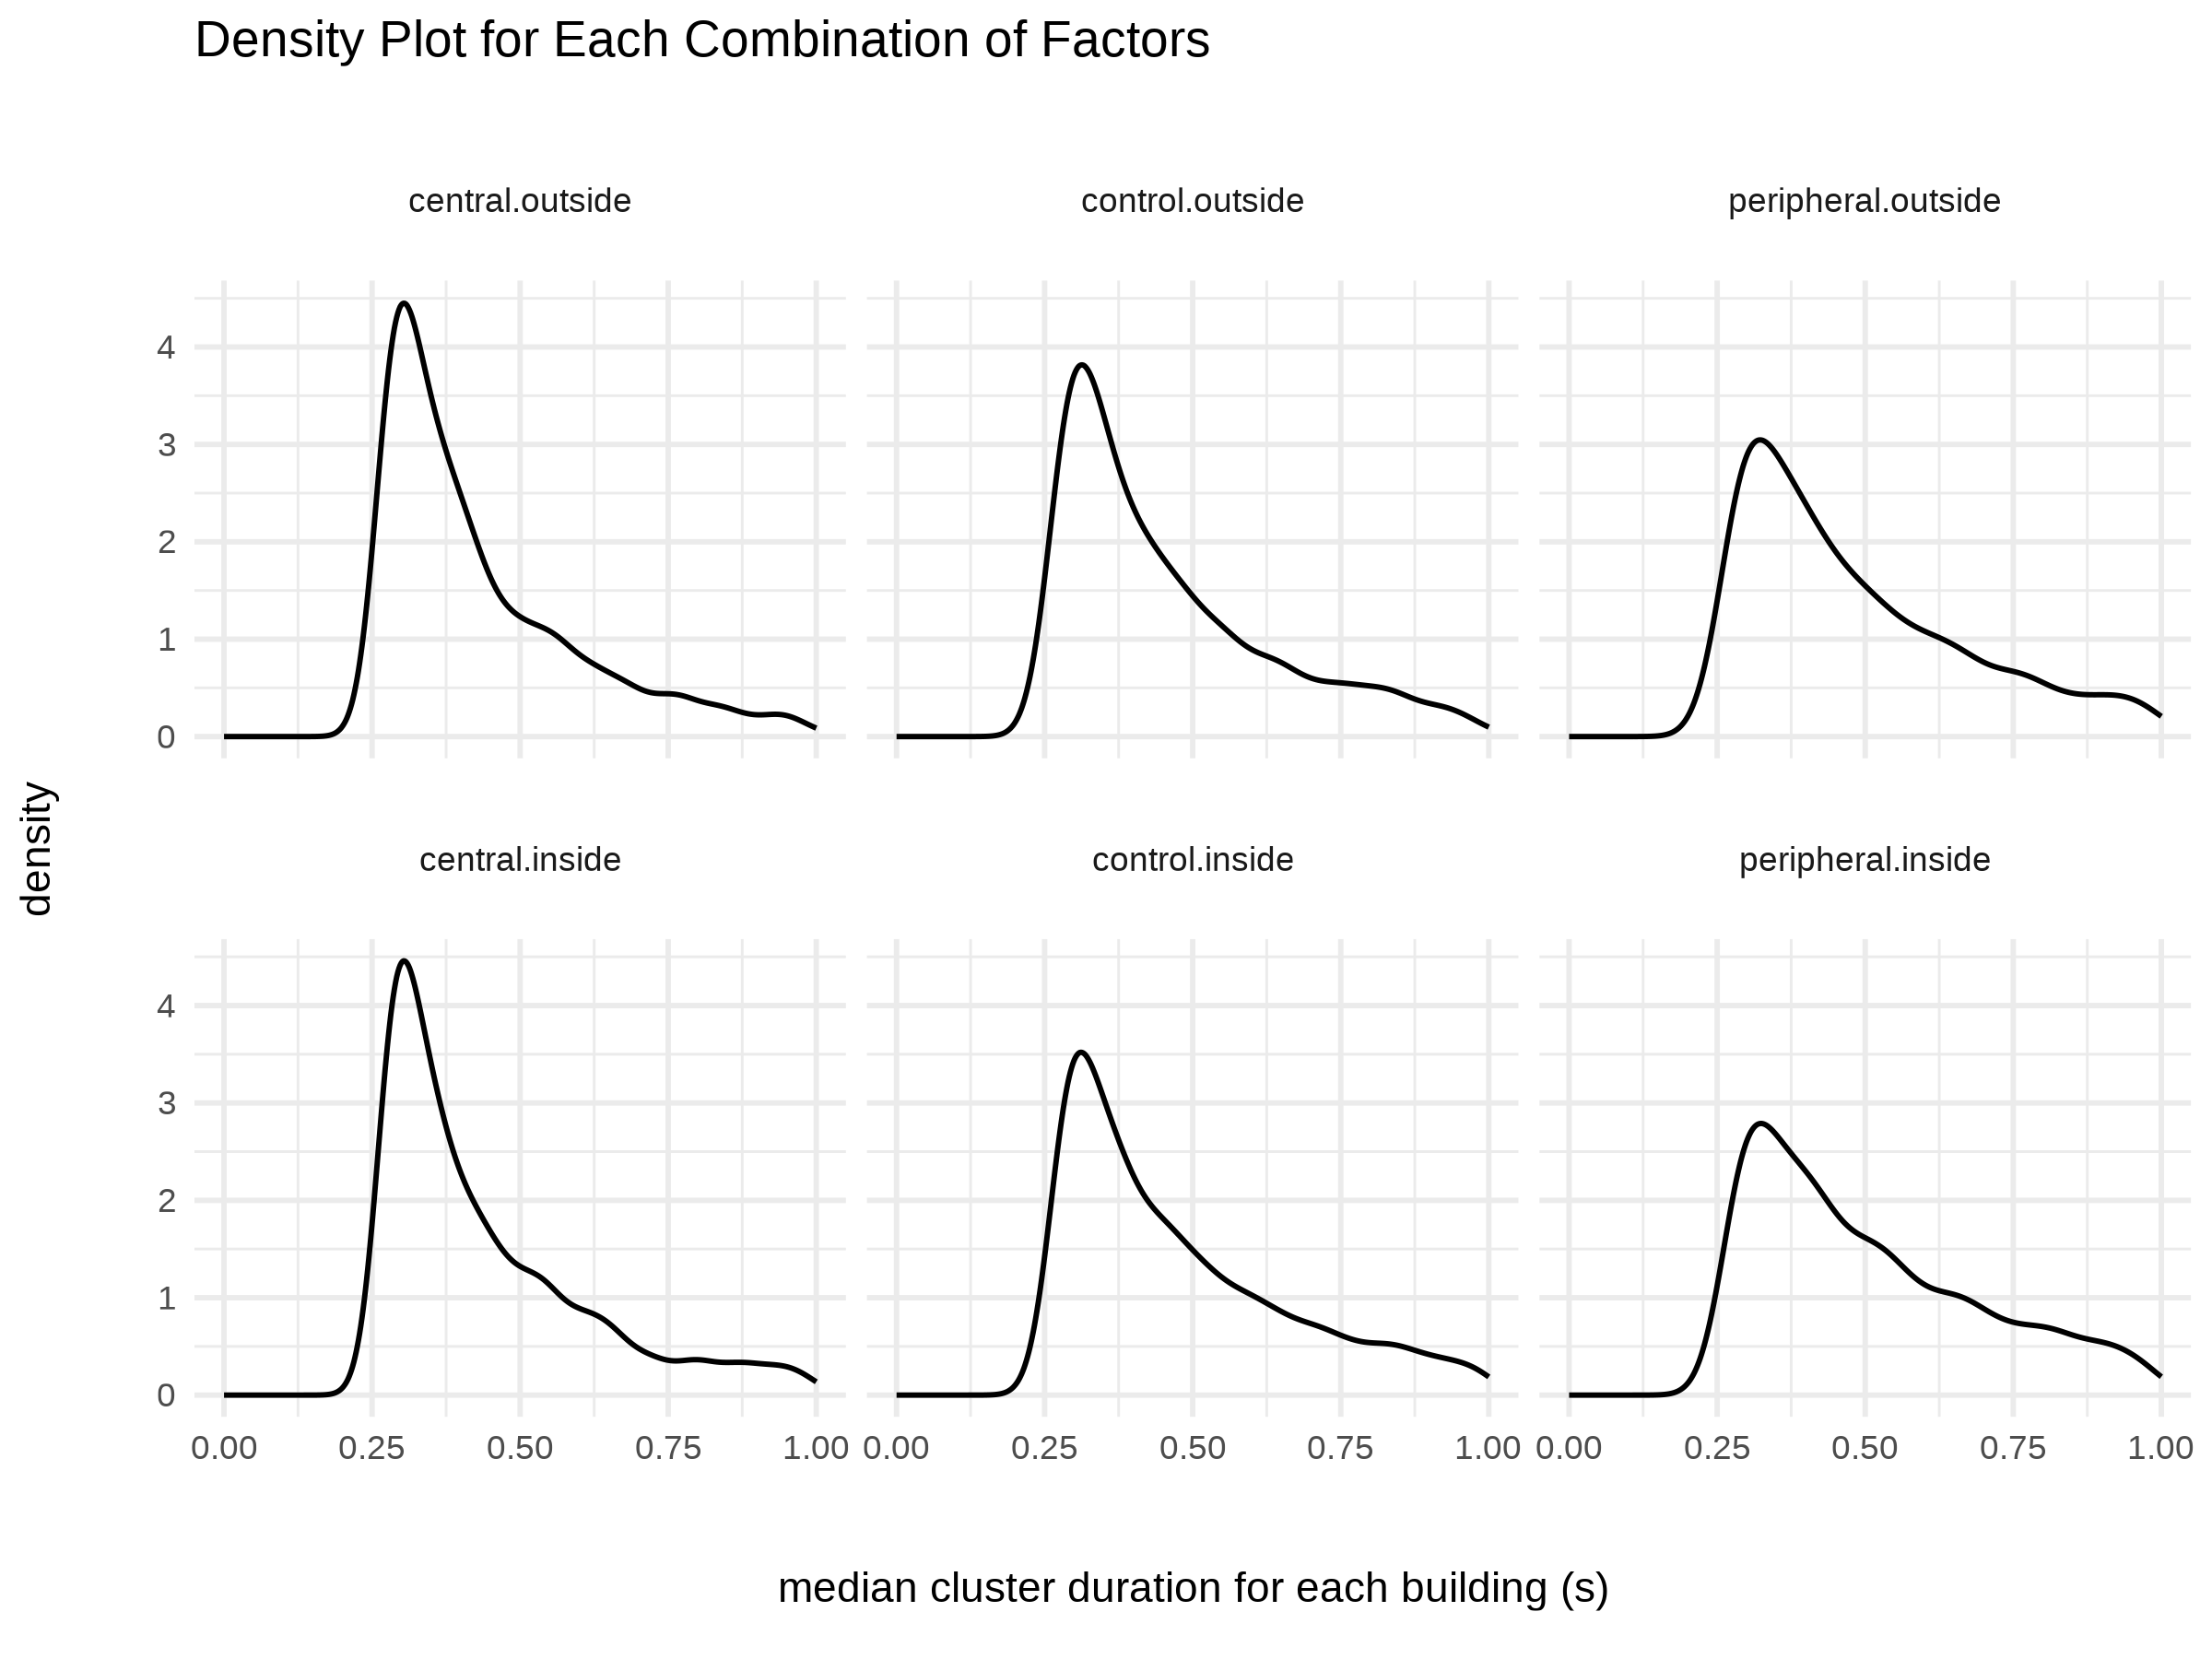

In [9]:
df_node |>
  ggplot(aes(x = clusterDuration)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  xlim(0,1)+
  facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
  theme_minimal() +
  labs(title = "Density Plot for Each Combination of Factors",
       x = "median cluster duration for each building (s)",
       y = "density")

In [22]:
df <- read_csv("graph_group_connections.csv")
df <- df |> 
    mutate(
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control")),
        hitObjectColliderName = factor(hitObjectColliderName)
    ) |>
    rename(
        group = category
    )

Rows: 1826 Columns: 4
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (2): PID, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [39]:
fig <- df |>
  ggplot(aes(x = connections, group = group, color = group)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  theme_minimal() +
  labs(title = "Node degree centrality distribution",
       x = "node degree",
       y = "density")
#ggsave("sim_node_degree_dist.svg", fig)
fig

df_node |>
    group_by(PID, building, group, building_location, connections) |>
    ungroup() |>
    filter(connections > 10) |>
    ggplot(aes(x = duration)) +
      geom_density(alpha = 0.6) +  # Adjust alpha for transparency
      xlim(0,1)+
      facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
      theme_minimal() +
      labs(title = "Density Plot (node-degree > 10)",
           x = "median cluster duration for each building (s)",
           y = "density")
ggsave("naisu_only_location_node_filter.svg", fig)

Saving 6.67 x 6.67 in image


In [64]:
df_rm_null <- df_group_node |> filter(connections > 0)

model <- glmer(connections ~  group * building_location + (1 | PID), data = df_rm_null, Gamma(link = "inverse"))

In [63]:
# Create a reference grid
ref_grid <- ref_grid(model)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ building_location)

# View results
summary(emm)
pairs(emm, adjust = "bonferroni")
pairs(emm, adjust = "tukey")

,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,4.350301,0.1925744,Inf,3.972862,4.727740
2,inside,6.887977,0.4680248,Inf,5.970666,7.805289


 contrast         estimate    SE  df z.ratio p.value
 outside - inside    -2.54 0.311 Inf  -8.147  <.0001

Results are averaged over the levels of: group 

 contrast         estimate    SE  df z.ratio p.value
 outside - inside    -2.54 0.311 Inf  -8.147  <.0001

Results are averaged over the levels of: group 

In [65]:
model
library(car)
Anova(model)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( inverse )
Formula: connections ~ group * building_location + (1 | PID)
   Data: df_rm_null
      AIC       BIC    logLik  deviance  df.resid 
 9238.169  9282.248 -4611.084  9222.169      1818 
Random effects:
 Groups   Name        Std.Dev.
 PID      (Intercept) 0.02747 
 Residual             0.57017 
Number of obs: 1826, groups:  PID, 24
Fixed Effects:
                         (Intercept)                          groupcentral  
                            0.237722                              0.003478  
                        groupcontrol               building_locationinside  
                           -0.024330                             -0.072348  
groupcentral:building_locationinside  groupcontrol:building_locationinside  
                           -0.017550                             -0.016438  

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
group,2.619834,2,2.698424e-01
building_location,310.818873,1,1.448236e-69
group:building_location,2.724093,2,2.561361e-01
